In [1]:
import numpy as np
import pandas as pd

# Loading data
matches = pd.read_csv("../data/matches.csv")
deliveries = pd.read_csv("../data/deliveries.csv")

# .shape returns rows and colums of dataset
print("Matches: ", matches.shape)
print("Deliveries:",deliveries.shape)



FileNotFoundError: [Errno 2] No such file or directory: '../data/matches.csv'

In [ ]:
# Peaking the data
matches.head()


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [ ]:
# Peaking Data
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [ ]:
# Selecting only needed columns
match_info = matches[['id', 'city', 'winner', 'target_runs']]
match_info.head()

,id,city,winner,target_runs
0,335982,Bangalore,Kolkata Knight Riders,223.0
1,335983,Chandigarh,Chennai Super Kings,241.0
2,335984,Delhi,Delhi Daredevils,130.0
3,335985,Mumbai,Royal Challengers Bangalore,166.0
4,335986,Kolkata,Kolkata Knight Riders,111.0


In [ ]:
# Same for deliveries we will slecte needed columns
ball_info = deliveries[['match_id', 'inning', 'batting_team', 'bowling_team', 
                        'over', 'ball', 'total_runs', 'is_wicket']]
print(ball_info.shape)
ball_info.head()

(260920, 8)


,match_id,inning,batting_team,bowling_team,over,ball,total_runs,is_wicket
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,1,0
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,0,0
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,1,0
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,0,0
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,0,0


In [ ]:
# We will take only second inning as for prediction we need to know the target runs and the team chasing the target
ball_info = ball_info[ball_info['inning'] == 2]
print("Shape after filtering 2nd innings: ", ball_info.shape)
ball_info.head()

Shape after filtering 2nd innings:  (125741, 8)


,match_id,inning,batting_team,bowling_team,over,ball,total_runs,is_wicket
124,335982,2,Royal Challengers Bangalore,Kolkata Knight Riders,0,1,1,0
125,335982,2,Royal Challengers Bangalore,Kolkata Knight Riders,0,2,1,0
126,335982,2,Royal Challengers Bangalore,Kolkata Knight Riders,0,3,0,0
127,335982,2,Royal Challengers Bangalore,Kolkata Knight Riders,0,4,1,0
128,335982,2,Royal Challengers Bangalore,Kolkata Knight Riders,0,5,1,0


In [ ]:
# joining Both columns match ifo and and ball info
merged = ball_info.merge(match_info,left_on='match_id',right_on='id')
print("Shape after merge: ", merged.shape)
merged.head()

Shape after merge:  (125741, 12)


,match_id,inning,batting_team,bowling_team,over,ball,total_runs,is_wicket,id,city,winner,target_runs
0,335982,2,Royal Challengers Bangalore,Kolkata Knight Riders,0,1,1,0,335982,Bangalore,Kolkata Knight Riders,223.0
1,335982,2,Royal Challengers Bangalore,Kolkata Knight Riders,0,2,1,0,335982,Bangalore,Kolkata Knight Riders,223.0
2,335982,2,Royal Challengers Bangalore,Kolkata Knight Riders,0,3,0,0,335982,Bangalore,Kolkata Knight Riders,223.0
3,335982,2,Royal Challengers Bangalore,Kolkata Knight Riders,0,4,1,0,335982,Bangalore,Kolkata Knight Riders,223.0
4,335982,2,Royal Challengers Bangalore,Kolkata Knight Riders,0,5,1,0,335982,Bangalore,Kolkata Knight Riders,223.0


In [ ]:
# Feature Engineering
merged['current_score'] = merged.groupby('match_id')['total_runs'].cumsum()
merged[['match_id', 'over', 'ball', 'total_runs', 'current_score']].head(10)

,match_id,over,ball,total_runs,current_score
0,335982,0,1,1,1
1,335982,0,2,1,2
2,335982,0,3,0,2
3,335982,0,4,1,3
4,335982,0,5,1,4
5,335982,0,6,0,4
6,335982,0,7,0,4
7,335982,1,1,0,4
8,335982,1,2,0,4
9,335982,1,3,4,8


In [ ]:
# Runs Left Column
merged['runs_left'] = merged['target_runs'] - merged['current_score']
merged[['match_id', 'current_score', 'target_runs', 'runs_left']].head(10)

,match_id,current_score,target_runs,runs_left
0,335982,1,223.0,222.0
1,335982,2,223.0,221.0
2,335982,2,223.0,221.0
3,335982,3,223.0,220.0
4,335982,4,223.0,219.0
5,335982,4,223.0,219.0
6,335982,4,223.0,219.0
7,335982,4,223.0,219.0
8,335982,4,223.0,219.0
9,335982,8,223.0,215.0


In [ ]:
merged['balls_bowled'] = merged['over'] * 6 + merged['ball']
merged['balls_left'] = 120 - merged['balls_bowled']
merged[['match_id', 'over', 'ball', 'balls_bowled', 'balls_left']].head(10)

,match_id,over,ball,balls_bowled,balls_left
0,335982,0,1,1,119
1,335982,0,2,2,118
2,335982,0,3,3,117
3,335982,0,4,4,116
4,335982,0,5,5,115
5,335982,0,6,6,114
6,335982,0,7,7,113
7,335982,1,1,7,113
8,335982,1,2,8,112
9,335982,1,3,9,111


In [ ]:
# Wicketts Left Column
merged['wickets_fallen'] = merged.groupby('match_id')['is_wicket'].cumsum()
merged['wickets_left'] = 10 - merged['wickets_fallen']

In [ ]:
# Current Run rate
merged['crr'] = (merged['current_score'] * 6) / merged['balls_bowled']

In [ ]:
# Require run rate
merged['rrr'] = (merged['runs_left'] * 6) / merged['balls_left']

In [ ]:
merged[['current_score', 'runs_left', 'balls_left', 'wickets_left', 'crr', 'rrr']].head(10)

,current_score,runs_left,balls_left,wickets_left,crr,rrr
0,1,222.0,119,10,6.000000,11.193277
1,2,221.0,118,10,6.000000,11.237288
2,2,221.0,117,10,4.000000,11.333333
3,3,220.0,116,10,4.500000,11.379310
4,4,219.0,115,10,4.800000,11.426087
5,4,219.0,114,10,4.000000,11.526316
6,4,219.0,113,10,3.428571,11.628319
7,4,219.0,113,9,3.428571,11.628319
8,4,219.0,112,9,3.000000,11.732143
9,8,215.0,111,9,5.333333,11.621622


In [ ]:
# Creating target variable
merged['batting_team_won'] = (merged['batting_team'] == merged['winner']).astype(int)
merged[['batting_team', 'winner', 'batting_team_won']].head(5)

,batting_team,winner,batting_team_won
0,Royal Challengers Bangalore,Kolkata Knight Riders,0
1,Royal Challengers Bangalore,Kolkata Knight Riders,0
2,Royal Challengers Bangalore,Kolkata Knight Riders,0
3,Royal Challengers Bangalore,Kolkata Knight Riders,0
4,Royal Challengers Bangalore,Kolkata Knight Riders,0


In [ ]:
final_df = merged[['batting_team', 'bowling_team', 'city', 'runs_left', 
                   'balls_left', 'wickets_left', 'target_runs', 'crr', 'rrr', 
                   'batting_team_won']]

final_df = final_df.dropna()

X = final_df.drop('batting_team_won', axis=1) #axis=0 → rows ki direction (neeche) → row drop/operate karna axis=1 → columns ki direction (daayein) → column drop/operate karna
y = final_df['batting_team_won']

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Target distribution:', y.value_counts(normalize=True))

X shape: (119713, 9)
y shape: (119713,)
Target distribution: batting_team_won
1    0.522099
0    0.477901
Name: proportion, dtype: float64


In [ ]:
from sklearn.preprocessing import LabelEncoder

encoders = {}
for col in ['batting_team', 'bowling_team', 'city']:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le

X.head()


,batting_team,bowling_team,city,runs_left,balls_left,wickets_left,target_runs,crr,rrr
0,16,8,2,222.0,119,10,223.0,6.0,11.193277
1,16,8,2,221.0,118,10,223.0,6.0,11.237288
2,16,8,2,221.0,117,10,223.0,4.0,11.333333
3,16,8,2,220.0,116,10,223.0,4.5,11.379310
4,16,8,2,219.0,115,10,223.0,4.8,11.426087


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Train:', X_train.shape, '| Test:', X_test.shape)

import numpy as np
print('inf count:', np.isinf(X_train).sum().sum())
print('nan count:', X_train.isna().sum().sum())


import numpy as np

X_train = X_train.replace([np.inf, -np.inf], np.nan).dropna()
y_train = y_train.loc[X_train.index]

X_test = X_test.replace([np.inf, -np.inf], np.nan).dropna()
y_test = y_test.loc[X_test.index]

print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (95770, 9) | Test: (23943, 9)
inf count: 302
nan count: 0
Train: (95468, 9) | Test: (23849, 9)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Scaled!')

Scaled!


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)
print('Trained!')

Trained!


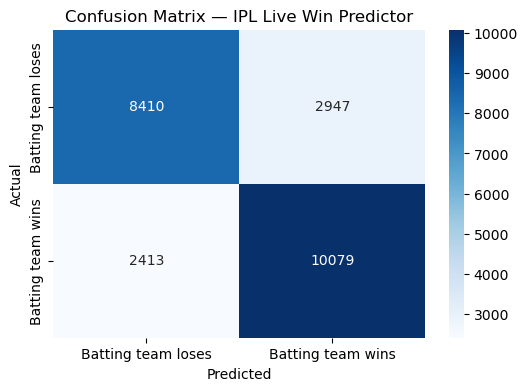

Accuracy:  0.7753
Precision: 0.7738
Recall:    0.8068
F1 Score:  0.7900

              precision    recall  f1-score   support

           0       0.78      0.74      0.76     11357
           1       0.77      0.81      0.79     12492

    accuracy                           0.78     23849
   macro avg       0.78      0.77      0.77     23849
weighted avg       0.78      0.78      0.77     23849



In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Batting team loses', 'Batting team wins'],
            yticklabels=['Batting team loses', 'Batting team wins'])
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion Matrix — IPL Live Win Predictor')
plt.show()

print(f'Accuracy:  {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_pred):.4f}')
print()
print(classification_report(y_test, y_pred))

In [ ]:
import joblib

joblib.dump(model, '../models/ipl_model.pkl')
joblib.dump(scaler, '../models/ipl_scaler.pkl')
joblib.dump(encoders, '../models/ipl_encoders.pkl')
joblib.dump(list(X.columns), '../models/ipl_features.pkl')

teams = sorted(merged['batting_team'].unique().tolist())
cities = sorted(merged['city'].dropna().unique().tolist())
joblib.dump(teams, '../models/ipl_teams.pkl')
joblib.dump(cities, '../models/ipl_cities.pkl')

print('Saved all files!')
print(f'Teams: {len(teams)}, Cities: {len(cities)}')

Saved all files!
Teams: 19, Cities: 36
